# NeXo v3.0 · Notebook 10 — Granger Causality Feature Gate

> **CRISP-DM Phase 4 — Modeling** (temporal causality / feature selection).
> **Input:** `curated/subscribers.parquet` + `processed/oss_aggregates.parquet` (from nb 01).
> **Output:** `granger_feature_gate.json` — (cause, effect, median_p, significant) edges.
> **Consumed by:** `services/api-gateway` `/granger-causality/lead-time` endpoint + dashboard Convergence panel.

## Pipeline
```
subscribers + oss_aggregates → area×month panel → Granger F-test per (cause→effect) pair
            → median p across areas → significance gate → granger_feature_gate.json
```

## Why Granger, not just correlation
Correlation says *X moves with Y*. **Granger causality** asks: *do past values of X improve the
prediction of Y beyond Y's own past?* i.e. *X moves BEFORE Y, with predictive power*.
Defense claim — "network anomalies precede customer complaints" — is a **directional, temporal**
statement → exactly what the Granger F-test measures (it is predictive precedence, not true causation).

## Reference
Granger, C.W.J. (1969). *Investigating Causal Relations by Econometric Models and Cross-spectral
Methods.* Econometrica 37(3), 424–438.

## What this notebook does NOT do
- Does NOT prove philosophical causation — Granger = predictive precedence only.
- Does NOT train an ML model — it is a statistical feature-selection gate.
- Does NOT rename the output JSON keys (`lag_max_months`, `significance_threshold`, `edges`,
  `significant_edges`) — they are an API contract consumed by api-gateway.

## Known methodology gaps (documented, not yet applied — see reports/10_findings.md)
ADF/KPSS stationarity gate · differencing · BIC lag selection · Benjamini–Hochberg FDR ·
reverse-Granger sanity test. These strengthen rigor but change the gate's numbers → applied
in a measured follow-up after the defense freeze.


## 1 · Imports

In [4]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from IPython.display import display

import io, json, os
from pathlib import Path
import boto3, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from botocore.client import Config
from statsmodels.tsa.stattools import grangercausalitytests
sns.set_theme(style='whitegrid')
s3 = boto3.client('s3', endpoint_url=os.environ.get('S3_ENDPOINT','http://localhost:9000'),
                  aws_access_key_id='minio', aws_secret_access_key='minio_pw',
                  config=Config(signature_version='s3v4'))

In [5]:
# ── Parameters (papermill-overridable) ──────────────────────────────────────
# This cell is tagged `parameters`. Values below feed the Granger gate.
# NOTE: the OUTPUT JSON keys (lag_max_months, significance_threshold, edges,
#   significant_edges) are an API contract and must NOT be renamed — only their
#   VALUES are parameterized here.
import os, random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

GRANGER_MAX_LAG  = 4          # test lags 1..4 months (max precedence horizon)
GRANGER_ALPHA    = 0.05       # significance threshold on the F-test p-value
MIN_PANEL_OBS    = 5          # skip an area with fewer than this many monthly points
GRANGER_FTEST    = 'ssr_ftest'  # statsmodels test key (sum-of-squared-residuals F-test)

# Causes (OSS KPIs) and effects (BSS experience metrics) to test
GRANGER_CAUSES   = ['integ', 'cdr', 'tput']
GRANGER_EFFECTS  = ['cem_target', 'rat_gap', 'churn']

GATE_FNAME       = 'granger_feature_gate.json'  # IMMUTABLE output name (api-gateway reads it)

print(f'SEED={SEED} | maxlag={GRANGER_MAX_LAG} | alpha={GRANGER_ALPHA} | '
      f'min_obs={MIN_PANEL_OBS} | causes={GRANGER_CAUSES} effects={GRANGER_EFFECTS}')


SEED=42 | maxlag=4 | alpha=0.05 | min_obs=5 | causes=['integ', 'cdr', 'tput'] effects=['cem_target', 'rat_gap', 'churn']


## 2 · Load curated subscribers + processed OSS aggregates

In [6]:
subs = pd.read_parquet(io.BytesIO(s3.get_object(Bucket='curated', Key='subscribers.parquet')['Body'].read()))
agg = pd.read_parquet(io.BytesIO(s3.get_object(Bucket='processed', Key='oss_aggregates.parquet')['Body'].read()))
print(f'subs: {len(subs):,}  agg: {len(agg):,}')

subs: 7,608,898  agg: 38,853


## 3 · Build area × month panel

BSS aggregated to (area, month). Join OSS aggregates to form panel data.

In [7]:
bss_p = subs.groupby(['area','month_year']).agg(
    cem_target=('cem_score_target','mean'),
    rat_gap=('rat_gap_score','mean'),
    churn=('churn_risk_flag','mean'),
).reset_index()
oss_p = agg.groupby(['area','month_year']).agg(
    integ=('avg_integrity','mean'),
    cdr=('avg_cdr','mean'),
    tput=('avg_throughput_mbps','mean'),
    cells=('cell_count','sum'),
).reset_index()
panel = oss_p.merge(bss_p, on=['area','month_year']).sort_values(['area','month_year'])
print(f'panel: {len(panel):,} (area × month)')
panel.head()

/tmp/ipykernel_7839/423721780.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bss_p = subs.groupby(['area','month_year']).agg(
/tmp/ipykernel_7839/423721780.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  oss_p = agg.groupby(['area','month_year']).agg(


panel: 72 (area × month)


,area,month_year,integ,cdr,tput,cells,cem_target,rat_gap,churn
0,Ariana,2026-01,99.879364,0.155896,NaN,421,0.652357,0.068914,0.000732
1,Ariana,2026-02,99.834007,0.194915,NaN,195,0.644260,0.090939,0.000854
2,Ariana,2026-03,99.854897,0.157337,NaN,194,0.644213,0.093432,0.000421
3,Ariana,2026-04,99.797295,0.239605,NaN,366,0.610120,0.203988,0.000493
4,Ariana,2026-05,99.800232,0.195294,NaN,391,0.597287,0.249740,0.000493


## 4 · Granger tests per (cause → effect) pair

Test lags 1..4 months. Take min p-value across lags. Significant: `p < 0.05`.

In [8]:
causes  = GRANGER_CAUSES
effects = GRANGER_EFFECTS
results = []
skipped = {'all_nan_cause': [], 'all_nan_effect': [], 'too_short': 0, 'test_error': 0}

# Pre-screen cause/effect columns — drop ones that are entirely NaN in the panel
live_causes  = [c for c in causes  if panel[c].notna().any() or skipped['all_nan_cause'].append(c)]
live_effects = [e for e in effects if panel[e].notna().any() or skipped['all_nan_effect'].append(e)]
if skipped['all_nan_cause']:
    print(f"[warn] all-NaN causes dropped: {skipped['all_nan_cause']}")
if skipped['all_nan_effect']:
    print(f"[warn] all-NaN effects dropped: {skipped['all_nan_effect']}")

for cause in live_causes:
    for effect in live_effects:
        pvals = []
        for area, g in panel.groupby('area', observed=True):
            ts = g[[effect, cause]].dropna()
            if len(ts) < MIN_PANEL_OBS:
                skipped['too_short'] += 1
                continue
            # statsmodels needs ≳ 3*maxlag+1 obs — cap maxlag by sample size
            maxlag = max(1, min(GRANGER_MAX_LAG, len(ts) // 3 - 1))
            if maxlag < 1:
                skipped['too_short'] += 1
                continue
            try:
                test = grangercausalitytests(ts, maxlag=maxlag, verbose=False)
                p = min(test[k][0][GRANGER_FTEST][1] for k in test)
                pvals.append(p)
            except Exception:
                skipped['test_error'] += 1
                continue
        if pvals:
            mp = float(np.median(pvals))
            results.append({'cause': cause, 'effect': effect,
                            'median_p': round(mp, 4),
                            'significant': mp < GRANGER_ALPHA,
                            'areas_tested': len(pvals)})

# Always build a DataFrame with the contract columns so downstream cells don't KeyError
RES_COLS = ['cause', 'effect', 'median_p', 'significant', 'areas_tested']
res_df = pd.DataFrame(results, columns=RES_COLS)
print(f"pairs evaluated: {len(res_df)} | too_short skips: {skipped['too_short']} | test errors: {skipped['test_error']}")
print(res_df if not res_df.empty else '[info] res_df is empty — likely too few monthly obs per area for any (cause, effect) pair')

/home/souhayl/projects/telecom-cloud-intelligence/.venv/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/souhayl/projects/telecom-cloud-intelligence/.venv/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/souhayl/projects/telecom-cloud-intelligence/.venv/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/souhayl/projects/telecom-cloud-intelligence/.venv/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/souhayl/projects/telecom-cloud-intelligence/.venv/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbo

pairs evaluated: 9 | too_short skips: 21 | test errors: 2
   cause      effect  median_p  significant  areas_tested
0  integ  cem_target    0.2432        False             8
1  integ     rat_gap    0.2230        False             8
2  integ       churn    0.1751        False             7
3    cdr  cem_target    0.2563        False             8
4    cdr     rat_gap    0.1435        False             8
5    cdr       churn    0.2229        False             7
6   tput  cem_target    0.1161        False             1
7   tput     rat_gap    0.1494        False             1
8   tput       churn    0.0380         True             1


/home/souhayl/projects/telecom-cloud-intelligence/.venv/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/souhayl/projects/telecom-cloud-intelligence/.venv/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


## 5 · Heatmap p-values

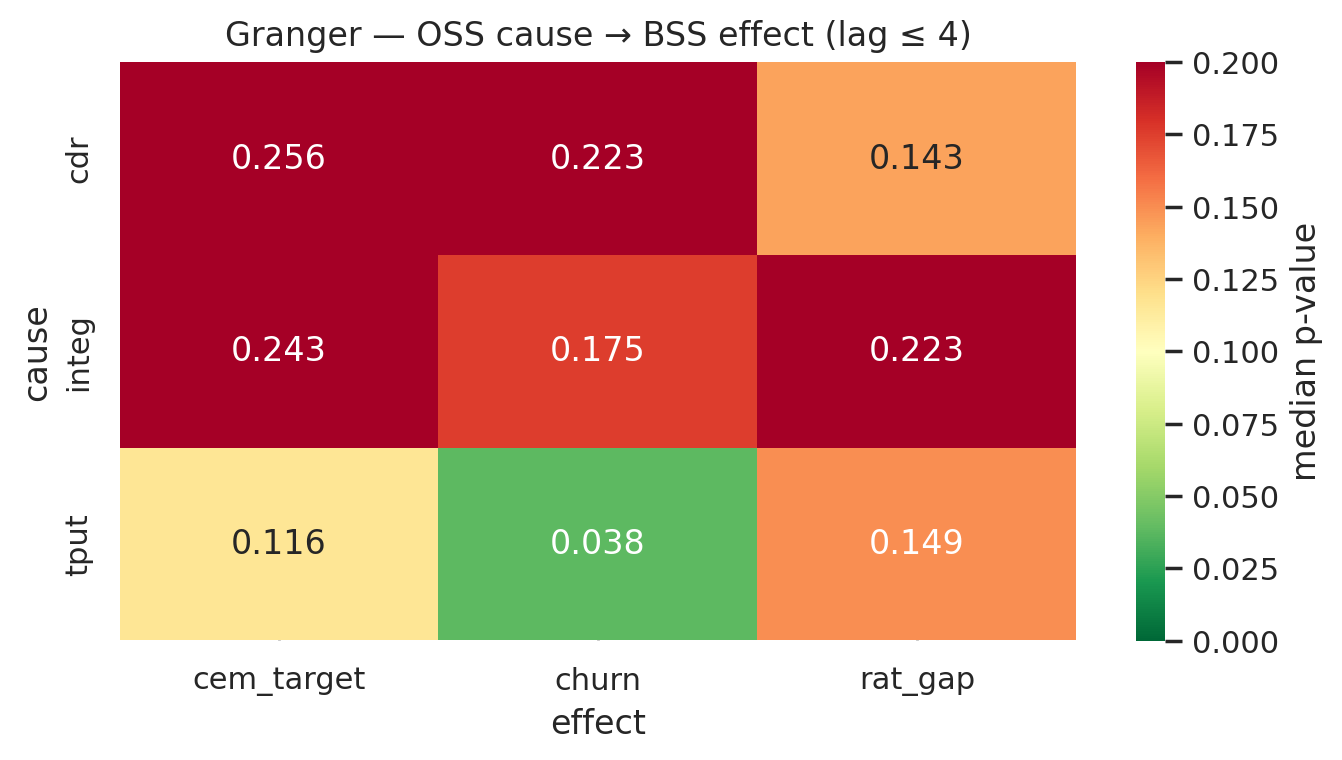

In [9]:
if res_df.empty or not {'cause', 'effect', 'median_p'}.issubset(res_df.columns):
    fig, ax = plt.subplots(figsize=(7, 2.5))
    ax.text(0.5, 0.5,
            'No Granger pairs survived — likely too few monthly obs per area.\n'
            'Increase panel depth (more months) or lower GRANGER_MAX_LAG.',
            ha='center', va='center', transform=ax.transAxes, color='#94A3B8')
    ax.set_axis_off()
    plt.tight_layout(); plt.show()
else:
    pv = res_df.pivot(index='cause', columns='effect', values='median_p')
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(pv, annot=True, fmt='.3f', cmap='RdYlGn_r', vmin=0, vmax=0.2, ax=ax,
                cbar_kws={'label': 'median p-value'})
    ax.set_title('Granger — OSS cause → BSS effect (lag ≤ {})'.format(GRANGER_MAX_LAG))
    plt.tight_layout(); plt.show()

## 6 · Write granger_feature_gate.json

Offline gate consumed by api-gateway's `/granger-causality/lead-time` endpoint.

In [10]:
gate = {
    'generated_at': pd.Timestamp.utcnow().isoformat(),
    'lag_max_months': GRANGER_MAX_LAG,
    'significance_threshold': GRANGER_ALPHA,
    'edges': res_df.to_dict(orient='records'),
    'significant_edges': res_df[res_df['significant']].to_dict(orient='records'),
}
out = Path(GATE_FNAME)
out.write_text(json.dumps(gate, indent=2))
print('Written', out)
print(json.dumps(gate, indent=2, default=str))
s3.put_object(Bucket='curated', Key=GATE_FNAME, Body=out.read_bytes())
print('↑ curated/granger_feature_gate.json')

Written granger_feature_gate.json
{
  "generated_at": "2026-05-25T05:37:17.972935+00:00",
  "lag_max_months": 4,
  "significance_threshold": 0.05,
  "edges": [
    {
      "cause": "integ",
      "effect": "cem_target",
      "median_p": 0.2432,
      "significant": false,
      "areas_tested": 8
    },
    {
      "cause": "integ",
      "effect": "rat_gap",
      "median_p": 0.223,
      "significant": false,
      "areas_tested": 8
    },
    {
      "cause": "integ",
      "effect": "churn",
      "median_p": 0.1751,
      "significant": false,
      "areas_tested": 7
    },
    {
      "cause": "cdr",
      "effect": "cem_target",
      "median_p": 0.2563,
      "significant": false,
      "areas_tested": 8
    },
    {
      "cause": "cdr",
      "effect": "rat_gap",
      "median_p": 0.1435,
      "significant": false,
      "areas_tested": 8
    },
    {
      "cause": "cdr",
      "effect": "churn",
      "median_p": 0.2229,
      "significant": false,
      "areas_tested": 7


## 7 · Two-tier Granger architecture — offline gate vs live engine

Until now this notebook has run the **offline gate**: a one-shot panel-grain
Granger test that writes `granger_feature_gate.json` to disk. That gate is
consumed at training time as a *feature-selection prior* — it tells the CEM,
VAE, and RAT models which OSS variables have historically Granger-caused CEM
movements.

The **live engine** is a different thing, running in a different container:

| Tier | Where it runs | Cadence | Output | Purpose |
|---|---|---|---|---|
| **Offline gate** (this nb) | `notebooks/10_granger_feature_selection.ipynb` | Manual / pre-training | `notebooks/granger_feature_gate.json` | Feature-selection prior for the model trainers |
| **Live engine** | `services/pipeline-worker/worker/analytics/granger.py` | Every pipeline cycle (~2 min) | `granger_causality_results` PG table | Real-time per-area causal pairs for L4 ConvergenceSpirit + `/granger-causality/forecast` API |

```
┌─────────────────────────┐                ┌──────────────────────────┐
│  this notebook (offline)│  json (prior)  │  CEM / VAE / RAT trainers│
│  area × month panel     ├───────────────►│  drop / weight features  │
│  MAX_LAG = 4 months     │                └──────────────────────────┘
└─────────────────────────┘

                              ┌───────────────────────────────────────┐
                              │ pipeline-worker  (LIVE — every cycle) │
                              │ analytics/granger.py                  │
                              │   ↓                                   │
                              │ INSERT INTO granger_causality_results │
                              └───────────────────┬───────────────────┘
                                                  │
                                                  ▼
                              ┌───────────────────────────────────────┐
                              │ api-gateway/routers/granger.py        │
                              │  /granger-causality           (list)  │
                              │  /granger-causality/summary    (agg)  │
                              │  /granger-causality/lead-time  (per-A)│
                              │  /granger-causality/forecast   (proj) │
                              │  /granger-causality/explain    (meta) │
                              └───────────────────┬───────────────────┘
                                                  │
                                                  ▼
                              ┌───────────────────────────────────────┐
                              │ dashboard                              │
                              │  /vae-anomalies → click governorate    │
                              │     pulls per-area causal pairs        │
                              │  /predictive  → causal projections     │
                              │     CEM_Y(t+lag) = a + b·OSS_X(t)      │
                              └───────────────────────────────────────┘
```

Cells below connect to PostgreSQL and visualize what the **live engine** has
produced so far. If the table is empty the cells degrade gracefully — there
is no synthetic backfill.

In [11]:
# ── Live-mode connection — PostgreSQL ───────────────────────────────────────
# Reads granger_causality_results (populated by services/pipeline-worker per cycle).
# Env vars (Docker network): PG_HOST=postgres, PG_PORT=5432.
# Local-host fallback: localhost:5432 (port 5432 published by docker-compose).
import os
import pandas as pd

PG_HOST     = os.environ.get('PG_HOST', 'localhost')
PG_PORT     = int(os.environ.get('PG_PORT', '5432'))
PG_DB       = os.environ.get('PG_DB', 'telecom_intel')
PG_USER     = os.environ.get('PG_USER', 'telecom')
PG_PASSWORD = os.environ.get('PG_PASSWORD', 'telecom_pw')

live_df = pd.DataFrame()  # remains empty if connection or table missing
try:
    import psycopg2
    with psycopg2.connect(
        host=PG_HOST, port=PG_PORT, dbname=PG_DB,
        user=PG_USER, password=PG_PASSWORD, connect_timeout=5,
    ) as conn:
        live_df = pd.read_sql(
            """
            SELECT area, oss_variable, cem_variable, direction,
                   max_lag, best_lag, best_pvalue, best_fstat,
                   significant, created_at
              FROM granger_causality_results
             ORDER BY created_at DESC
             LIMIT 1000;
            """,
            conn,
        )
    print(f'[live] rows from granger_causality_results: {len(live_df):,}')
except Exception as e:
    print(f'[live] could not read live table ({type(e).__name__}): {e}')
    print('       (this is fine — the offline gate above stands on its own)')

if not live_df.empty:
    print('latest:', live_df['created_at'].max())
    print('areas :', live_df['area'].nunique())
    print('pairs :', live_df.groupby(['oss_variable','cem_variable']).ngroups)
    display(live_df.head(8))

[live] rows from granger_causality_results: 62
latest: 2026-05-25 00:26:41.692279+00:00
areas : 24
pairs : 5


/tmp/ipykernel_7839/3768787037.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  live_df = pd.read_sql(


,area,oss_variable,cem_variable,direction,max_lag,best_lag,best_pvalue,best_fstat,significant,created_at
0,Beja,avg_throughput,avg_cem_score,avg_throughput→avg_cem_score,2,1,0.197749,2.204346,False,2026-05-25 00:26:41.692279+00:00
1,Ben Arous,avg_throughput,avg_cem_score,avg_throughput→avg_cem_score,2,1,0.112225,3.705134,False,2026-05-25 00:26:41.692279+00:00
2,Manouba,avg_throughput,avg_cem_score,avg_throughput→avg_cem_score,2,1,0.448396,0.675968,False,2026-05-25 00:26:41.692279+00:00
3,Sfax,avg_throughput,avg_cem_score,avg_throughput→avg_cem_score,2,1,0.348528,1.069179,False,2026-05-25 00:26:41.692279+00:00
4,Siliana,avg_throughput,avg_cem_score,avg_throughput→avg_cem_score,2,1,0.167763,2.600276,False,2026-05-25 00:26:41.692279+00:00
5,Zaghouen,avg_throughput,avg_cem_score,avg_throughput→avg_cem_score,2,1,0.253925,1.660594,False,2026-05-25 00:26:41.692279+00:00
6,Ariana,avg_throughput,underserved_pct,avg_throughput→underserved_pct,2,2,0.001713,582.624480,True,2026-05-25 00:26:41.692279+00:00
7,Siliana,avg_throughput,underserved_pct,avg_throughput→underserved_pct,2,2,0.000118,8460.997319,True,2026-05-25 00:26:41.692279+00:00


## 8 · Live results — visualization

Two views on what the live engine produced:

1. **Significance count per area** — which governorates already have causal
   evidence collected (more cycles → more significant pairs).
2. **Lag distribution** — what temporal precedence (in pipeline cycles) the
   prod engine is finding between OSS and CEM. Tight clusters near small lags
   are the strongest defense narrative (network change → fast CEM hit).

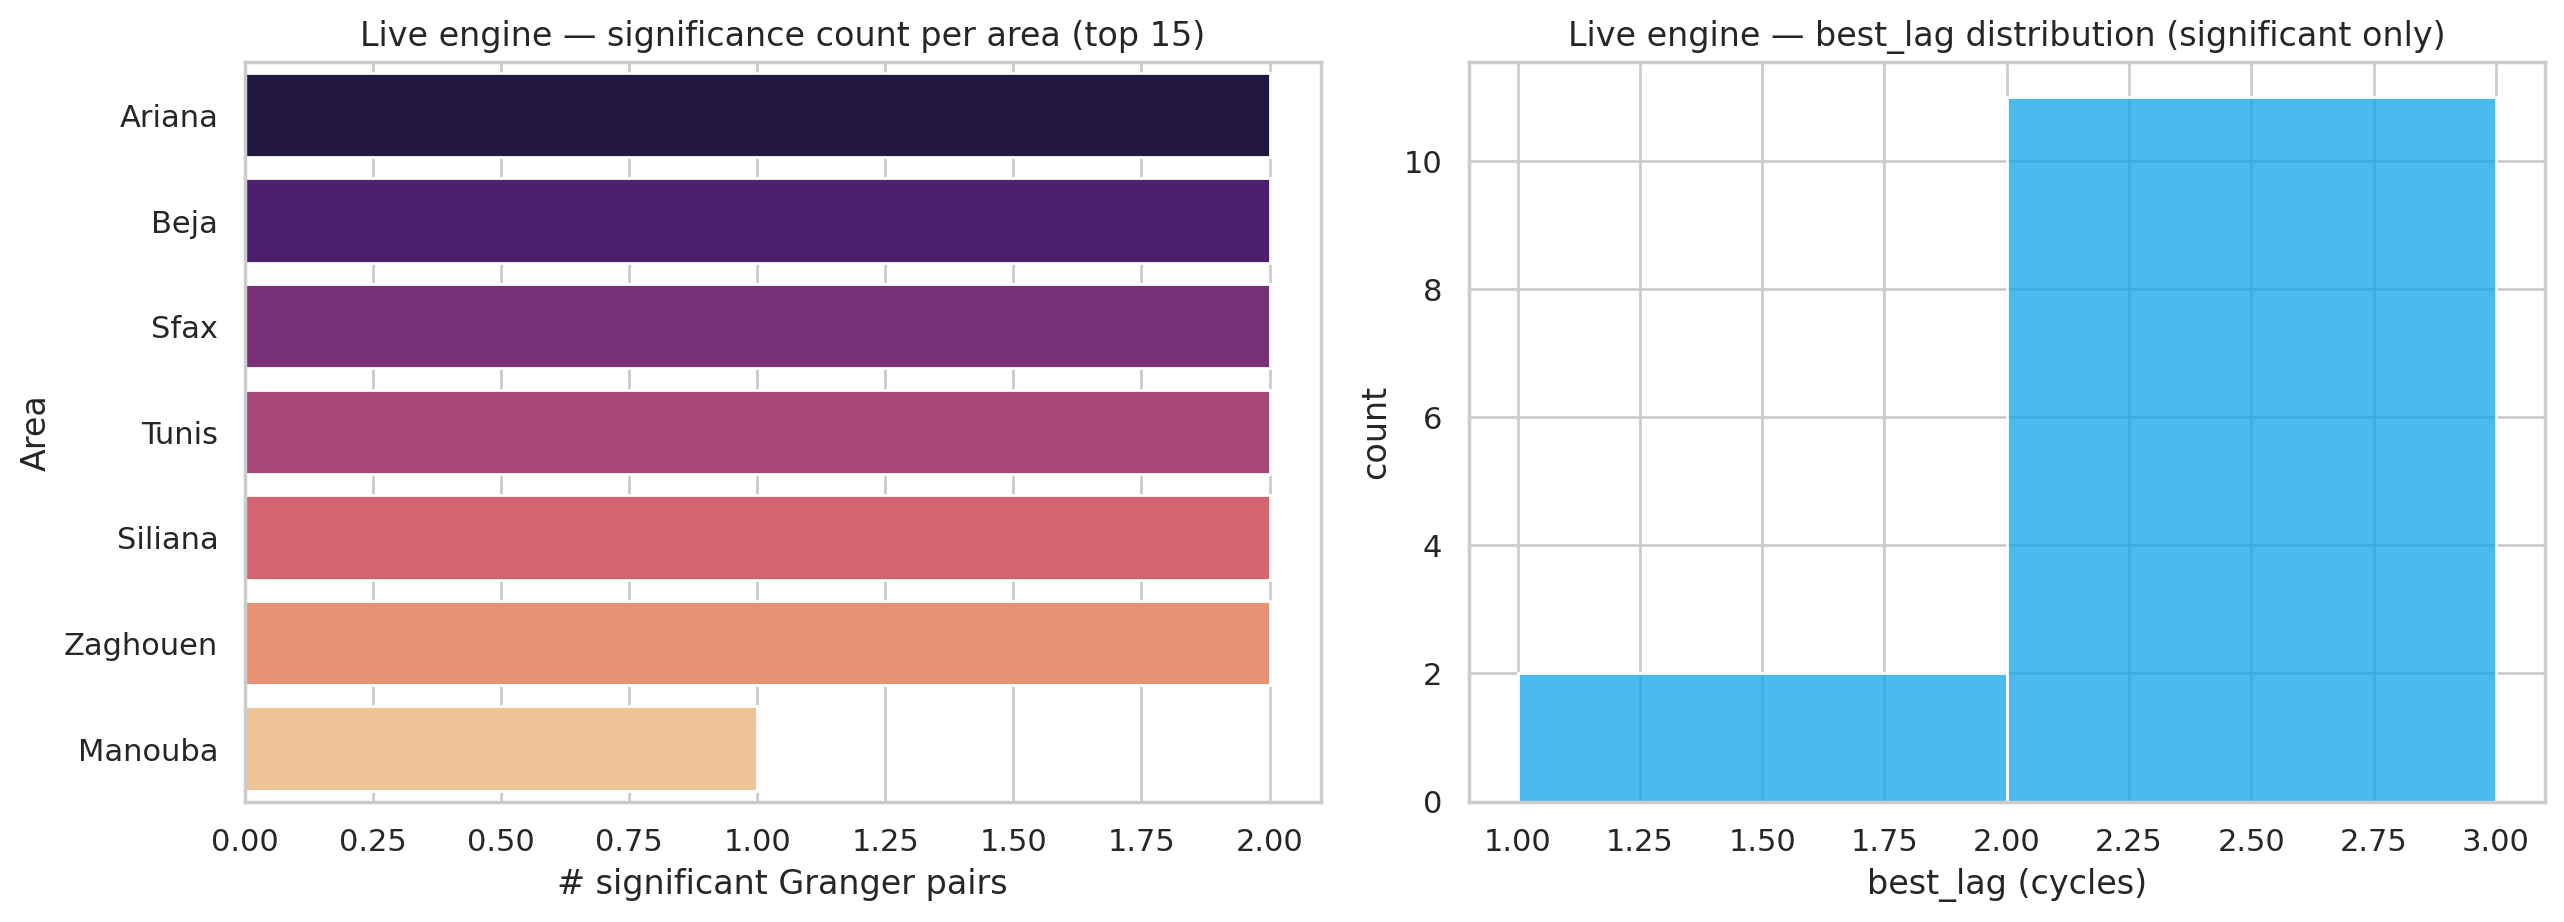


Lead-time table (lag_window=43,200 min/lag):


,avg_lag,min_pvalue,n,avg_lead_time_min
area,,,,
Manouba,1.0,4.214386e-02,1,43200.0
Beja,1.5,3.804272e-08,2,64800.0
Ariana,2.0,1.713431e-03,2,86400.0
Sfax,2.0,1.902948e-07,2,86400.0
Siliana,2.0,9.497657e-06,2,86400.0
Tunis,2.0,4.368682e-08,2,86400.0
Zaghouen,2.0,1.520425e-07,2,86400.0


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

if live_df.empty:
    print('[live] table is empty — start the pipeline-worker for ≥3 cycles, then re-run cell 8.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    # ── Left: significance count per area (top 15) ─────────────────────────
    sig_per_area = (
        live_df[live_df['significant']]
        .groupby('area').size()
        .sort_values(ascending=False).head(15)
    )
    if sig_per_area.empty:
        axes[0].text(0.5, 0.5, 'No significant pairs yet',
                     ha='center', va='center', transform=axes[0].transAxes,
                     fontsize=12, color='#94A3B8')
        axes[0].set_axis_off()
    else:
        sns.barplot(x=sig_per_area.values, y=sig_per_area.index,
                    hue=sig_per_area.index, palette='magma',
                    orient='h', legend=False, ax=axes[0])
        axes[0].set_xlabel('# significant Granger pairs')
        axes[0].set_ylabel('Area')
        axes[0].set_title('Live engine — significance count per area (top 15)')

    # ── Right: best_lag distribution (significant pairs only) ──────────────
    sig = live_df[live_df['significant']]
    if sig.empty:
        axes[1].text(0.5, 0.5, 'No significant pairs yet',
                     ha='center', va='center', transform=axes[1].transAxes,
                     fontsize=12, color='#94A3B8')
        axes[1].set_axis_off()
    else:
        sns.histplot(sig['best_lag'], bins=range(1, int(sig['best_lag'].max())+2),
                     color='#0EA5E9', edgecolor='white', ax=axes[1])
        axes[1].set_xlabel('best_lag (cycles)')
        axes[1].set_ylabel('count')
        axes[1].set_title('Live engine — best_lag distribution (significant only)')

    plt.tight_layout()
    plt.show()

    # ── Lead-time table (mirrors /granger-causality/lead-time endpoint) ────
    LAG_WINDOW_MIN = int(os.environ.get('LAG_WINDOW_MINUTES', '43200'))
    lead_tbl = (
        live_df[live_df['significant']]
        .assign(lead_time_min=lambda d: d['best_lag'] * LAG_WINDOW_MIN)
        .groupby('area')
        .agg(avg_lag=('best_lag', 'mean'),
             min_pvalue=('best_pvalue', 'min'),
             n=('best_lag', 'count'),
             avg_lead_time_min=('lead_time_min', 'mean'))
        .sort_values('avg_lead_time_min')
        .head(10)
    )
    print(f'\nLead-time table (lag_window={LAG_WINDOW_MIN:,} min/lag):')
    display(lead_tbl)

## 9 · Dashboard contract — where these results surface

The live-engine table is the **only** data source for these dashboard
features (no mock, no Math.random anywhere in the chain):

| Page / panel | Endpoint | Reads |
|---|---|---|
| `/vae-anomalies` → governorate detail panel | `/granger-causality?limit=500` | Causal pairs filtered to the selected governorate, lag, p-value, human-readable cause copy |
| `/predictive` (Forecast) | `/granger-causality/forecast?area=X` | OLS `CEM_Y(t) ~ a + b·OSS_X(t−best_lag)` on `area_network_health`, projected at t+lag |
| `/granger-causality` (methodology page) | `/granger-causality/explain` | Hypothesis, parameters, convergence narrative |
| L4 ConvergenceSpirit (autonomous) | `/granger-causality?significant_only=true` | Significant pairs used to schedule preemptive actions |
| `/granger-causality/lead-time` | `/granger-causality/lead-time?area=X` | Detection lead time per (oss, cem) pair |

**Defense narrative.** The offline gate (§1-§6) tells the trainers
*which OSS features matter*. The live engine (§7-§8) tells the dashboard
*by how much* and *with what lead-time*, per area, per cycle. Together
they realize the O+B convergence research contribution claimed in the
proposal: *we don't just correlate OSS and CEM — we measure the lag at
which OSS predicts CEM, then act inside that lag window*.